In [1]:
import os
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
from datetime import datetime as dt, timedelta
from tiingo import TiingoClient
import requests

# Load API keys from a local secrets file (kept out of version control via .gitignore)
try:
    _secrets_dir = os.path.dirname(os.path.abspath(__file__))  # works when run as a .py script
except NameError:
    _secrets_dir = os.getcwd()  # fallback for notebooks, where __file__ is not defined

with open(os.path.join(_secrets_dir, "secrets.json")) as f:
    secrets = json.load(f)

config = {
    "api_key": secrets["tiingo_api_key"]
}
client = TiingoClient(config)

api_key2 = secrets["polygon_api_key"]


In [28]:
# Directory where this notebook/script lives, so files load regardless of the current working directory
try:
    SCRIPT_DIR = os.path.dirname(os.path.abspath(__file__))  # works when run as a .py script
except NameError:
    SCRIPT_DIR = os.getcwd()  # fallback for notebooks, where __file__ is not defined

def load_data(file_path):
    return pd.read_excel(os.path.join(SCRIPT_DIR, file_path), index_col=0, parse_dates=True)

bond1 = 'ZFL.TO.xlsx'
bond2 = 'ZFM.TO.xlsx'
equity = 'VFV.TO.xlsx'
gold = 'CGL.TO.xlsx'

bond1_df = load_data(bond1)
bond2_df = load_data(bond2)
equity_df = load_data(equity)
gold_df = load_data(gold)

print("Bond Long:", bond1_df.head())
print("Bond Mid:", bond2_df.head())
print("Equity (VFV.TO)", equity_df.head())
print("Gold (CGL.TO)", gold_df.head())

Bond Long:              Open   High    Low  Close  Volume
Date                                          
2026-06-18  12.24  12.27  12.23  12.27    8054
2026-06-17  12.18  12.21  12.13  12.13   94200
2026-06-16  12.13  12.17  12.13  12.16   18000
2026-06-15  12.17  12.18  12.08  12.10   14500
2026-06-12  12.13  12.14  12.08  12.14   45500
Bond Mid:              Open   High    Low  Close Volume
Date                                         
2026-06-18  14.85  14.86  14.85  14.86    200
2026-06-17  14.85  14.86  14.81  14.81  95500
2026-06-16  14.84  14.85  14.84  14.85   2900
2026-06-15  14.86  14.87  14.83  14.83   9200
2026-06-12  14.79  14.83  14.79  14.82  12800
Equity (VFV.TO)               Open    High     Low   Close  Volume
Date                                              
2026-06-18  187.92  188.37  187.33  188.25  146605
2026-06-17  187.25  187.55  185.73  186.15  374200
2026-06-16  188.14  188.27  186.80  186.80  235300
2026-06-15  187.11  188.30  187.07  187.78  284600
2026-0

In [29]:
# Data cleaning
def clean_data(df):
    df = df.dropna().copy()
    df['Returns'] = np.log(df['Close'] / df['Close'].shift(1)) #Computing Log returns (vectorized)
    return df

dataframes = {'bond1': bond1_df, 'bond2': bond2_df, 'equity': equity_df, 'gold': gold_df}

dataframes = {key: clean_data(df) for key, df in dataframes.items()}

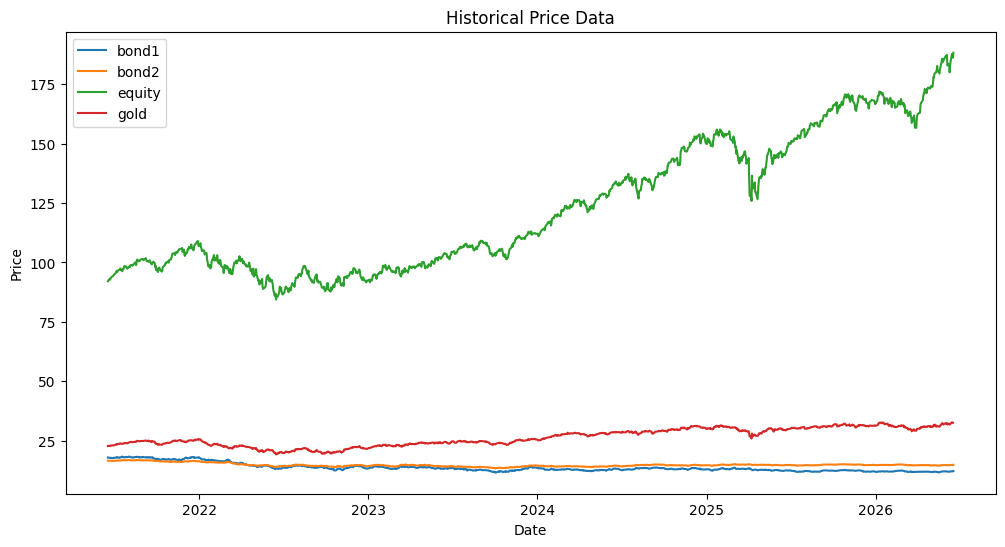

In [30]:
# Plotting historical prices for all assets
plt.figure(figsize=(12,6))
for key, df in dataframes.items():
    plt.plot(df.index, df['Close'], label=key)
plt.xlabel('Date')
plt.ylabel('Price')
plt.title('Historical Price Data')
plt.legend()
plt.show()

In [31]:
#Compute Volatility
def comp_vol(df, window=30):
    return df['Returns'].rolling(window).std()*np.log(252)

for key in dataframes:
    dataframes[key].loc[:, 'Volatility'] = comp_vol(dataframes[key])

print(dataframes)

{'bond1':              Open   High    Low  Close  Volume   Returns  Volatility
Date                                                                
2026-06-18  12.24  12.27  12.23  12.27    8054       NaN         NaN
2026-06-17  12.18  12.21  12.13  12.13   94200 -0.011476         NaN
2026-06-16  12.13  12.17  12.13  12.16   18000  0.002470         NaN
2026-06-15  12.17  12.18  12.08  12.10   14500 -0.004946         NaN
2026-06-12  12.13  12.14  12.08  12.14   45500  0.003300         NaN
...           ...    ...    ...    ...     ...       ...         ...
2021-06-24  17.80  17.87  17.80  17.87   17582  0.009559    0.039084
2021-06-23  17.77  17.77  17.71  17.77   10190 -0.005612    0.038961
2021-06-22  17.71  17.82  17.71  17.82   15884  0.002810    0.037737
2021-06-21  17.85  17.85  17.78  17.82    9091  0.000000    0.037719
2021-06-18  17.77  17.97  17.77  17.97   47852  0.008382    0.038706

[1255 rows x 7 columns], 'bond2':              Open   High    Low  Close Volume   Returns  V

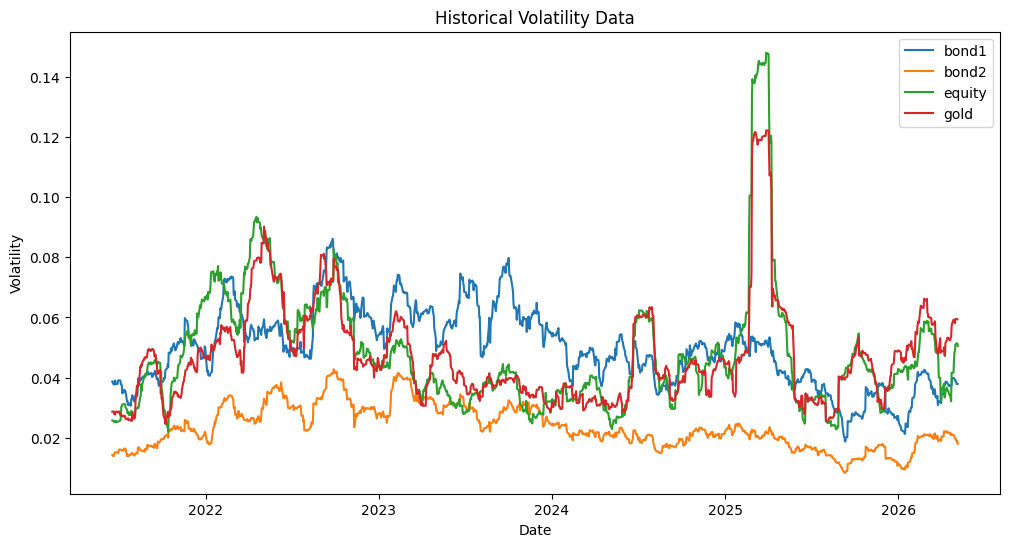

In [32]:
# Plotting volatility
plt.figure(figsize=(12,6))
for key, df in dataframes.items():
    plt.plot(df.index, df['Volatility'], label=key)
plt.xlabel('Date')
plt.ylabel('Volatility')
plt.title('Historical Volatility Data')
plt.legend()
plt.show()

In [33]:
#Cleaning Tbills data
dfT = pd.read_excel("tbill_3mnth.xlsx")
dfT.columns = ['date', 'rf']
dfT['date'] = pd.to_datetime(dfT['date'], errors='coerce')
dfT['rf'] = pd.to_numeric(dfT['rf'], errors='coerce')
dfT = dfT.dropna(subset=['rf'])
dfT['rf'] = dfT['rf']/100
dfT['rf_daily'] = (1+dfT['rf'])**(1/252) - 1
dfT['rf_log_daily'] = np.log(1+dfT['rf_daily'])
dfT


,date,rf,rf_daily,rf_log_daily
1,2026-06-16,0.0229,0.000090,0.000090
4,2026-06-02,0.0232,0.000091,0.000091
7,2026-05-19,0.0232,0.000091,0.000091
10,2026-05-05,0.0232,0.000091,0.000091
13,2026-04-21,0.0229,0.000090,0.000090
...,...,...,...,...
2075,2000-02-29,0.0505,0.000196,0.000196
2078,2000-02-15,0.0510,0.000197,0.000197
2081,2000-02-01,0.0521,0.000202,0.000202
2084,2000-01-18,0.0508,0.000197,0.000197


In [51]:
# Getting market data for option variables
symbol = "NVDA"
df = client.get_dataframe(symbol, startDate='2020-01-01', endDate=dt.today() - timedelta(days=1))
df = df.sort_index(ascending=False)   # Most recent date first
print(df)

log_returns = np.log(df['adjClose']/df['adjClose'].shift(1))
S = df['close'].iloc[1]  # Last Close Price
print(S)
opt_exp = dt(2026, 7, 31)   # Expiration date (matches the option chain queried below)
T = (opt_exp - dt.now()).total_seconds() / (365 * 24 * 60 * 60)    # Time till expiration (in years)
print(T)
r = dfT['rf_log_daily'].iloc[1]    # Risk-free rate using 3 month Tbills
print(r)
sigma = log_returns.std()*np.sqrt(252)  # Volatility of underlying asset
print(sigma)

params = {
    "underlying_ticker": symbol,
    "contract_type": "call",
    "expiration_date": "2026-07-31",
    "strike_price.gte": round(S * 0.9, 0),  
    "strike_price.lte": round(S * 1.15, 0),   
    "expired": "false",
    "sort": "strike_price",
    "order": "asc",
    "limit": 250,
    "apiKey": api_key2,
}


# Reference endpoint: contract metadata (strikes only) - allowed on the free plan.
# Option prices / IV come from the snapshot endpoint, which requires a paid plan.
res = requests.get("https://api.polygon.io/v3/reference/options/contracts", params=params).json()

K = [c["strike_price"] for c in res["results"]]   # strikes for the chain
S_underlying = S                                  # underlying spot (already from Tiingo)
print(K)


                            close    high     low    open     volume  \
date                                                                   
2026-07-01 00:00:00+00:00  197.58  199.85  193.45  196.20  146147597   
2026-06-30 00:00:00+00:00  200.09  200.63  195.11  197.24  166476665   
2026-06-29 00:00:00+00:00  194.97  196.18  189.80  193.85  148835724   
2026-06-26 00:00:00+00:00  192.53  195.55  191.22  193.12  179304147   
2026-06-25 00:00:00+00:00  195.74  200.80  192.13  200.08  150205647   
...                           ...     ...     ...     ...        ...   
2020-01-08 00:00:00+00:00  240.38  242.04  238.15  239.76    6931017   
2020-01-07 00:00:00+00:00  239.93  241.77  236.39  238.20    7980144   
2020-01-06 00:00:00+00:00  237.06  237.27  231.27  232.32    6572812   
2020-01-03 00:00:00+00:00  236.07  237.83  234.10  235.10    5144308   
2020-01-02 00:00:00+00:00  239.91  239.91  236.72  238.75    5941969   

                             adjClose     adjHigh      adjLow  

In [35]:
# Probability/Conditional Functions
def N(d):
    return norm.cdf(d)

def N_prime(d):
    return norm.pdf(d)

In [53]:
# Black-Scholes option pricing model (A Physics model with no friction, i.e. it prices options under ideal conditions)
def black_scholes(S, K, T, r, sigma, option_type='call'):
    if T <= 0:
        # Option has expired: value equals intrinsic value (no time value left)
        if option_type == 'call':
            return max(S - K, 0.0)
        elif option_type == 'put':
            return max(K - S, 0.0)
        else:
            raise ValueError("Invalid option type. Must be 'call' or 'put'.")

    d1 = (np.log(S/K)+(r+(sigma**2)/2)*T)/(sigma*np.sqrt(T))
    d2 = d1 - sigma*np.sqrt(T)

    if option_type == 'call':
        return S*N(d1) - K*(np.e**((-r)*T))*N(d2)
    elif option_type == 'put':
        return K*np.e**(-r*T) * N(-d2) - S*N(-d1)
    else:
        raise ValueError("Invalid option type. Must be 'call' or 'put'.")
    
# Market > B-S => opt is expensive, Market < B-S => opt is cheap
# Traders also exctract implied volatility from B-S !!DO THIS NEXT

blackScholes = pd.DataFrame({
    "Strike Price": K,
    "B-S Call": [black_scholes(S,strike,T,r,sigma,'call') for strike in K],
    "B-S Put": [black_scholes(S,strike,T,r,sigma,'put') for strike in K]
})
display(blackScholes)


,Strike Price,B-S Call,B-S Put
0,180,23.834479,3.743198
1,185,20.272246,5.180929
2,190,17.041966,6.950614
3,195,14.157984,9.066597
4,200,11.623415,11.531992
5,205,9.430679,14.339221
6,210,7.562925,17.471431
7,215,5.996028,20.904498
8,220,4.700862,24.609296
9,225,3.645550,28.553949


In [54]:
# Calulcating Greeks
d1 = (np.log(S/K)+(r+(sigma**2)/2)*T)/(sigma*np.sqrt(T))
d2 = d1 - sigma*np.sqrt(T)

# Delta
def delta(S, K, T, r, sigma, option_type='call'):
    d1 = (np.log(S/K)+(r+(sigma**2)/2)*T)/(sigma*np.sqrt(T))
    if option_type=='call':
        return N(d1)
    elif option_type=='put':
        return N(d1) - 1

# Gamma
def gamma(S,K,T,r,sigma):
    d1 = (np.log(S/K)+(r+(sigma**2)/2)*T)/(sigma*np.sqrt(T))
    return N_prime(d1)/(S*sigma*np.sqrt(T))

# Theta
def theta(S, K, T, r, sigma, option_type='call'):
    d1 = (np.log(S/K)+(r+(sigma**2)/2)*T)/(sigma*np.sqrt(T))
    d2 = d1 - sigma*np.sqrt(T)
    if option_type == 'call':
        return ((-S*N_prime(d1)*sigma)/(2*np.sqrt(T))) - (r*K*(np.e**(-r*T))*N(d2))
    elif option_type == 'put':
        return ((-S*N_prime(d1)*sigma)/(2*np.sqrt(T))) + (r*K*(np.e**(-r*T))*N(-d2))
    else:
        print("Option type must be 'put' or 'call'")

# Vega
def vega(S, K, T, r, sigma):
    d1 = (np.log(S/K)+(r+(sigma**2)/2)*T)/(sigma*np.sqrt(T))
    return S*N_prime(d1)*np.sqrt(T)

# Rho
def rho(S, K, T, r, sigma, option_type='call'):
    d1 = (np.log(S/K)+(r+(sigma**2)/2)*T)/(sigma*np.sqrt(T))
    d2 = d1 - sigma*np.sqrt(T)
    if option_type == 'call':
        return K*T*(np.e**(-r*T))*N(d2)
    elif option_type == 'put':
        return -K*T*(np.e**(-r*T))*N(-d2)
    else:
        print("Option type must be 'put' or 'call'")

In [55]:
# Greeks Calculations for given stock

def build_greeks(option_type):
    return pd.DataFrame({
    "Strike Price": K,
    "Delta": [delta(S, strike, T, r, sigma, option_type) for strike in K],
    "Gamma": [gamma(S, strike, T, r, sigma) for strike in K],
    "Theta": [theta(S, strike, T, r, sigma, option_type) for strike in K],
    "Vega":  [vega(S, strike, T, r, sigma) for strike in K],
    "Rho":   [rho(S, strike, T, r, sigma, option_type) for strike in K],
})

greeks_put = build_greeks('put')
greeks_call = build_greeks('call')

print(f"Greeks for {symbol} (call)")
display(greeks_call)

print(f"Greeks for {symbol} (put)")
display(greeks_put)


Greeks for NVDA (call)


,Strike Price,Delta,Gamma,Theta,Vega,Rho
0,180,0.788542,0.009960,-53.772950,16.190522,10.473217
1,185,0.729954,0.011382,-61.445127,18.501289,9.835132
2,190,0.666041,0.012524,-67.611325,20.358555,9.087785
3,195,0.598750,0.013309,-71.844103,21.633583,8.260504
4,200,0.530190,0.013692,-73.913124,22.256993,7.386052
5,205,0.462430,0.013671,-73.795516,22.221886,6.497398
6,210,0.397326,0.013274,-71.655004,21.577558,5.624873
7,215,0.336392,0.012560,-67.798752,20.416506,4.794066
8,220,0.280735,0.011601,-62.623104,18.858084,4.024568
9,225,0.231038,0.010478,-56.558793,17.032007,3.329573


Greeks for NVDA (put)


,Strike Price,Delta,Gamma,Theta,Vega,Rho
0,180,-0.211458,0.009960,-53.756568,16.190522,-3.600971
1,185,-0.270046,0.011382,-61.428290,18.501289,-4.630005
2,190,-0.333959,0.012524,-67.594033,20.358555,-5.768302
3,195,-0.401250,0.013309,-71.826356,21.633583,-6.986533
4,200,-0.469810,0.013692,-73.894922,22.256993,-8.251934
5,205,-0.537570,0.013671,-73.776859,22.221886,-9.531538
6,210,-0.602674,0.013274,-71.635892,21.577558,-10.795013
7,215,-0.663608,0.012560,-67.779185,20.416506,-12.016770
8,220,-0.719265,0.011601,-62.603082,18.858084,-13.177217
9,225,-0.768962,0.010478,-56.538316,17.032007,-14.263162


In [56]:
# Monte Carlo Pricing Model
# Simulate terminal prices once; the strike only enters the payoff, not the simulation.
def simulate_terminal(S, r, sigma, T, N, seed=None):
    rng = np.random.default_rng(seed)
    Z = rng.standard_normal(N)
    return S*np.exp((r - 0.5*sigma**2)*T + sigma*np.sqrt(T)*Z)

n_sims = 10000000
St = simulate_terminal(S, r, sigma, T, n_sims)   # one simulation, reused for all strikes
disc = np.exp(-r*T)

mc = pd.DataFrame({
    "Strike Price": K,
    "MC Call": [disc * np.maximum(St - strike, 0).mean() for strike in K],
    "MC Put":  [disc * np.maximum(strike - St, 0).mean() for strike in K],
})
display(mc)

,Strike Price,MC Call,MC Put
0,180,23.825217,3.744341
1,185,20.263448,5.182536
2,190,17.033568,6.952620
3,195,14.150435,9.069453
4,200,11.617408,11.536389
5,205,9.426115,14.345061
6,210,7.559655,17.478565
7,215,5.993431,20.912306
8,220,4.699047,24.617886
9,225,3.644691,28.563495


In [57]:
# Comparing Monte Carlo and Black-Scholes models
print("Monte Carlo and Black-Scholes comparison")
mc_bs = pd.DataFrame({
    "Strike Price": K,
    "MC Call":  [disc * np.maximum(St - strike, 0).mean() for strike in K],
    "B-S Call": [black_scholes(S, strike, T, r, sigma, 'call') for strike in K],
    "MC Put":   [disc * np.maximum(strike - St, 0).mean() for strike in K],
    "B-S Put":  [black_scholes(S, strike, T, r, sigma, 'put') for strike in K],
})

mc_bs["Call Diff"] = (mc_bs["MC Call"] - mc_bs["B-S Call"]).abs()
mc_bs["Put Diff"]  = (mc_bs["MC Put"]  - mc_bs["B-S Put"]).abs()

# Optional: reorder columns
mc_bs = mc_bs[["Strike Price", "MC Call", "B-S Call", "Call Diff",
               "MC Put", "B-S Put", "Put Diff"]]
display(mc_bs)

Monte Carlo and Black-Scholes comparison


,Strike Price,MC Call,B-S Call,Call Diff,MC Put,B-S Put,Put Diff
0,180,23.825217,23.834479,0.009262,3.744341,3.743198,0.001143
1,185,20.263448,20.272246,0.008798,5.182536,5.180929,0.001607
2,190,17.033568,17.041966,0.008399,6.952620,6.950614,0.002006
3,195,14.150435,14.157984,0.007549,9.069453,9.066597,0.002856
4,200,11.617408,11.623415,0.006007,11.536389,11.531992,0.004397
5,205,9.426115,9.430679,0.004564,14.345061,14.339221,0.005841
6,210,7.559655,7.562925,0.003270,17.478565,17.471431,0.007135
7,215,5.993431,5.996028,0.002596,20.912306,20.904498,0.007809
8,220,4.699047,4.700862,0.001815,24.617886,24.609296,0.008590
9,225,3.644691,3.645550,0.000859,28.563495,28.553949,0.009546


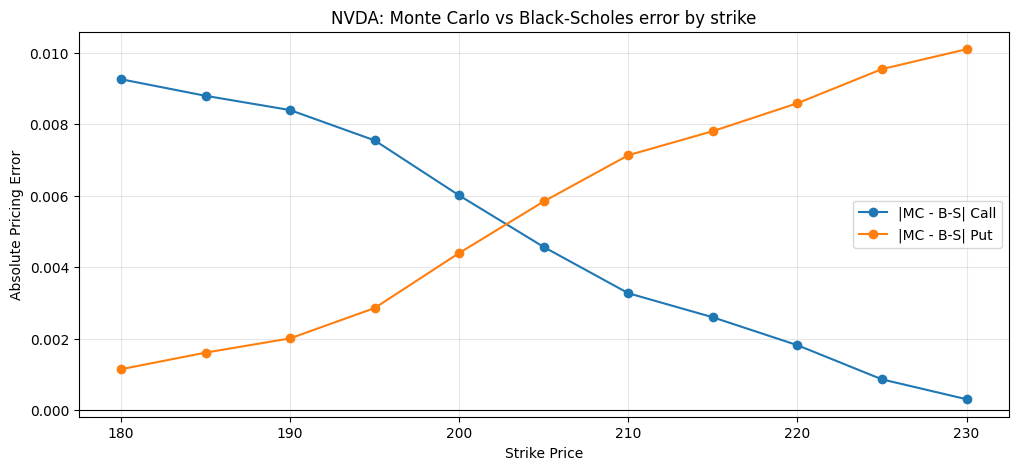

In [58]:
plt.figure(figsize=(12, 5))
plt.plot(mc_bs["Strike Price"], mc_bs["Call Diff"], 'o-', label="|MC - B-S| Call")
plt.plot(mc_bs["Strike Price"], mc_bs["Put Diff"],  'o-', label="|MC - B-S| Put")
plt.axhline(0, color='k', lw=0.8)
plt.xlabel("Strike Price"); plt.ylabel("Absolute Pricing Error")
plt.title(f"{symbol}: Monte Carlo vs Black-Scholes error by strike")
plt.legend(); plt.grid(True, alpha=0.3)
plt.show()

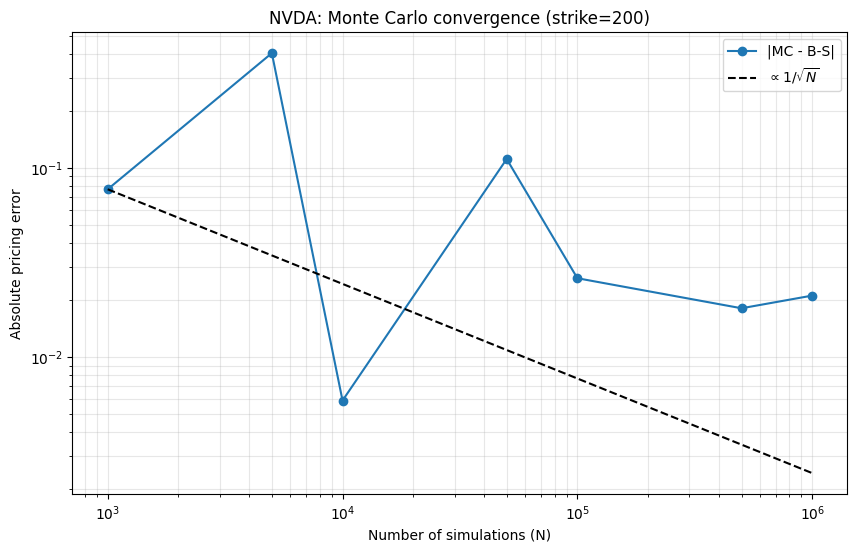

In [59]:
# Monte Carlo convergence: pricing error vs number of simulations
Ns = [1000, 5000, 10000, 50000, 100000, 500000, 1000000]

# Study one strike (ATM = closest to spot)
strike = min(K, key=lambda k: abs(k - S))
bs = black_scholes(S, strike, T, r, sigma, 'call')   # exact reference value

errors = []
for n in Ns:
    St_n = simulate_terminal(S, r, sigma, T, n)
    mc = np.exp(-r*T) * np.maximum(St_n - strike, 0).mean()
    errors.append(abs(mc - bs))

plt.figure(figsize=(10, 6))
plt.loglog(Ns, errors, 'o-', label="|MC - B-S|")
# Theoretical 1/sqrt(N) reference, anchored at the first point
plt.loglog(Ns, errors[0]*np.sqrt(Ns[0]/np.array(Ns)), 'k--', label=r"$\propto 1/\sqrt{N}$")
plt.xlabel("Number of simulations (N)")
plt.ylabel("Absolute pricing error")
plt.title(f"{symbol}: Monte Carlo convergence (strike={strike:.0f})")
plt.legend(); plt.grid(True, which='both', alpha=0.3)
plt.show()

In [48]:
# Implied Volatility Algorithm
# B-S: C = f(sigma), C = B-S price, f(sigma) is, smooth continous and strictly inc in sigma
# Conceptually finding f(sigma) - Market Price = 0

# MC: Conceptually solving MC Price(sigma) ± error = Market Price 

